<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    

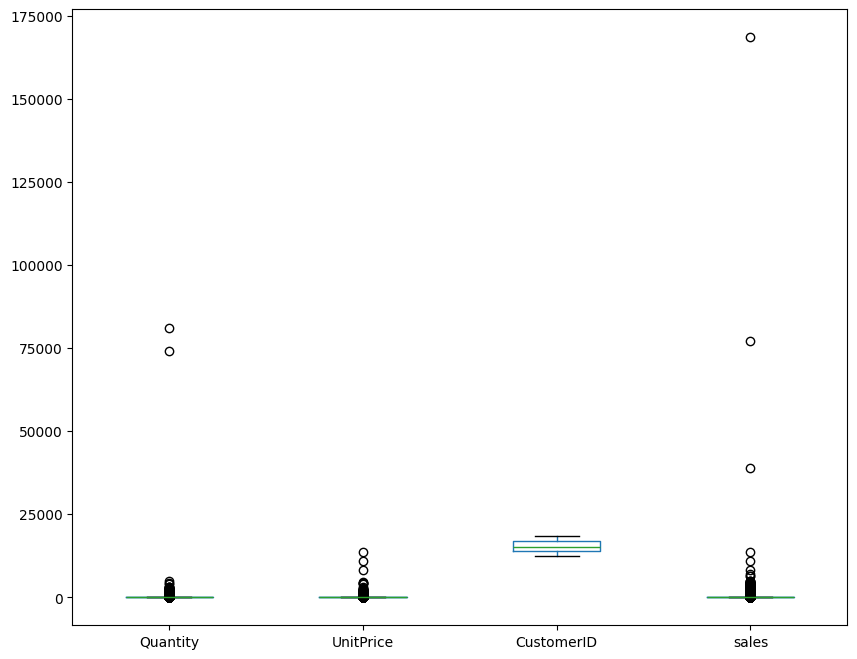

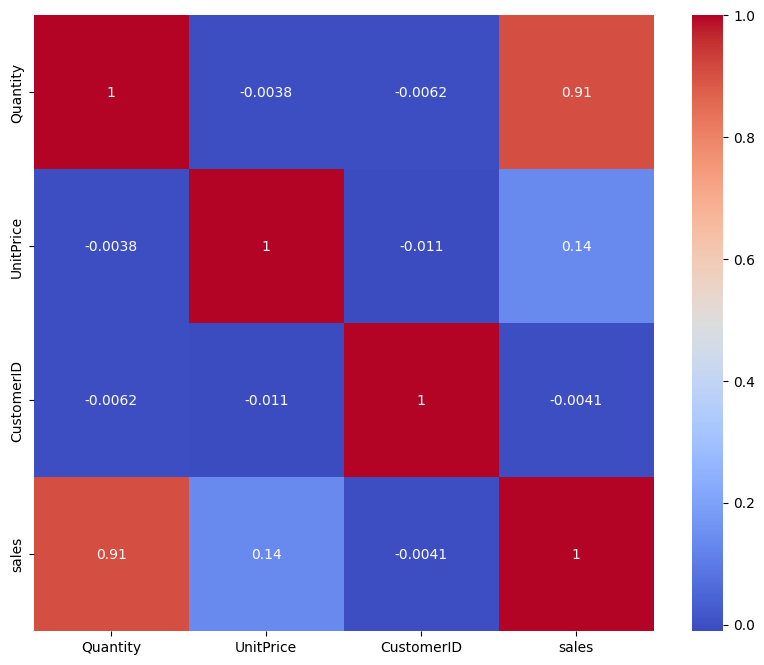

            Quantity      UnitPrice     CustomerID          sales
count  530104.000000  530104.000000  397884.000000  530104.000000
mean       10.542037       3.907625   15294.423453      20.121871
std       155.524124      35.915681    1713.141560     270.356743
min         1.000000       0.001000   12346.000000       0.001000
25%         1.000000       1.250000   13969.000000       3.750000
50%         3.000000       2.080000   15159.000000       9.900000
75%        10.000000       4.130000   16795.000000      17.700000
max     80995.000000   13541.330000   18287.000000  168469.600000


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel('online_retail.xlsx')
print(df.info())
print(df.head())
print(df.describe())
print(df.isnull().sum().sort_values(ascending=False))
print('duplicated:')
print(df.duplicated().sum())
print(df.drop_duplicates())

# Outliers handling
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Feature engineering
df['sales'] = df['Quantity']*df['UnitPrice']
df = df.drop(['Description','InvoiceDate'], axis=1)
print(df.info())

# Visualize
df.boxplot(figsize=(10,8), grid=False)
plt.show()

num = df.select_dtypes(include='number')
plt.figure(figsize=(10,8))
sns.heatmap(num.corr(), annot=True, cmap='coolwarm')
plt.show()

print(df.describe())

Best K = 4


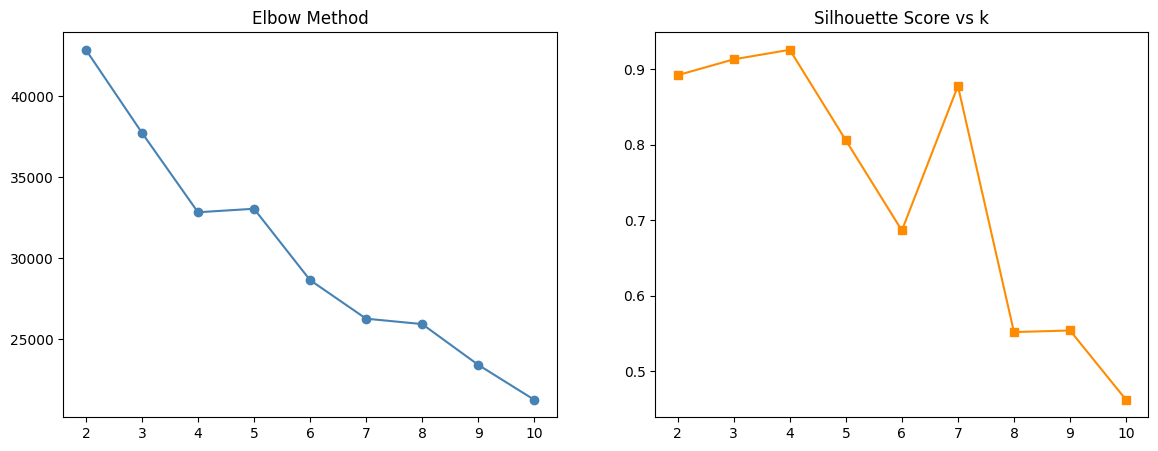

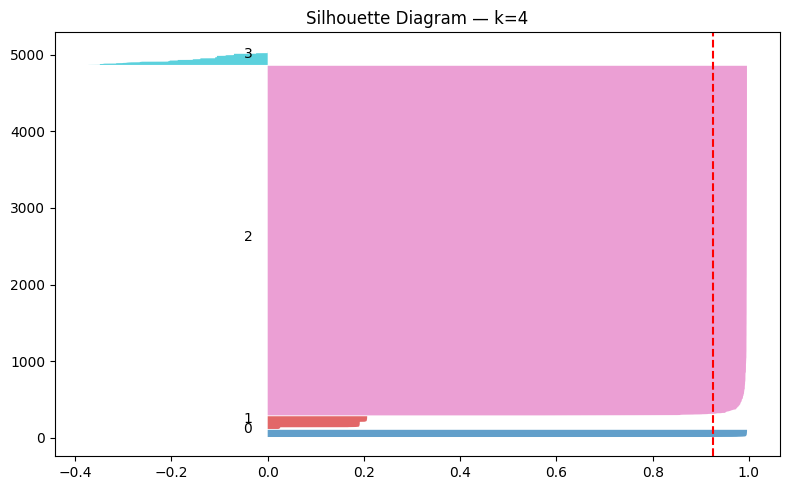

                          Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz  Time(s)
Model                                                                                     
KMeans (MiniBatch)               4      0.9263          1.3375             1009.6      0.6
Agglomerative Clustering         4      0.9201          1.2032             1239.0      0.2
Spectral Clustering              4     -0.8552          4.0836               19.5      0.4
DBSCAN                          18      0.9898          0.1017           333804.6      0.1


In [17]:
import time, warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN, SpectralClustering, MiniBatchKMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings("ignore")

SAMPLE_N, K_RANGE, PCA_DIMS = 5_000, range(2, 11), 10

# Preprocess
X_num = df[["sales"]].values
X_cat_enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit_transform(df[["Country"]])
X_scaled = StandardScaler().fit_transform(np.hstack([X_num, X_cat_enc]))
X_pca = PCA(n_components=PCA_DIMS, random_state=42).fit_transform(X_scaled)

rng = np.random.default_rng(42)
X_sample = X_pca[idx := rng.choice(len(X_pca), size=min(SAMPLE_N, len(X_pca)), replace=False)]

# Find best K
inertias, sil_scores = [], []
for k in K_RANGE:
    mbkm = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=4096)
    labels = mbkm.fit_predict(X_sample)
    inertias.append(mbkm.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=5_000, random_state=42))

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f"Best K = {best_k}")

# Visualize Elbow + Silhouette score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_RANGE), inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method")
axes[1].plot(list(K_RANGE), sil_scores, marker="s", color="darkorange")
axes[1].set_title("Silhouette Score vs k")
plt.show()

# Silhouette diagram 
labels_best = MiniBatchKMeans(n_clusters=best_k, random_state=42, n_init=3, batch_size=4096).fit_predict(X_sample)
sil_vals = silhouette_samples(X_sample, labels_best)
avg_sil  = silhouette_score(X_sample, labels_best)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower, colors = 10, plt.cm.tab10(np.linspace(0, 1, best_k))
for i in range(best_k):
    vals = np.sort(sil_vals[labels_best == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + len(vals) / 2, str(i))
    y_lower = y_upper + 10
ax.axvline(avg_sil, color="red", linestyle="--", label=f"Avg sil = {avg_sil:.3f}")
ax.set_title(f"Silhouette Diagram — k={best_k}")
plt.tight_layout(); plt.show()

# Try several models 
models = {
    "KMeans (MiniBatch)":       (MiniBatchKMeans(n_clusters=best_k, random_state=42, n_init=3, batch_size=4096), X_pca,   X_sample, idx),
    "Agglomerative Clustering": (AgglomerativeClustering(n_clusters=best_k),                                     X_sample, X_sample, None),
    "Spectral Clustering":      (SpectralClustering(n_clusters=best_k, random_state=42, affinity="nearest_neighbors", n_jobs=-1), X_sample, X_sample, None),
    "DBSCAN":                   (DBSCAN(eps=0.5, min_samples=5, n_jobs=-1),                                      X_sample, X_sample, None),
}

results = []
for name, (model, X_fit, X_met, sidx) in models.items():
    t0 = time.time()
    model.fit(X_fit)
    labels = model.predict(X_met) if sidx is not None else model.labels_
    elapsed = round(time.time() - t0, 1)

    n_cls = len(set(labels)) - (1 if -1 in labels else 0)
    if n_cls < 2:
        results.append({"Model": name, "Clusters": n_cls, "Silhouette": None, "Davies-Bouldin": None, "Calinski-Harabasz": None, "Time(s)": elapsed})
        continue

    mask = labels != -1
    Xm, lm = X_met[mask], labels[mask]
    results.append({"Model": name, "Clusters": n_cls,
                    "Silhouette":        round(silhouette_score(Xm, lm, sample_size=5_000, random_state=42), 4),
                    "Davies-Bouldin":    round(davies_bouldin_score(Xm, lm), 4),
                    "Calinski-Harabasz": round(calinski_harabasz_score(Xm, lm), 1),
                    "Time(s)": elapsed})

# Evaluate
print(pd.DataFrame(results).set_index("Model").to_string())

In [13]:
# After fitting Agglomerative Clustering (best model)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import numpy as np

# Re-run best model on sample (already done above, reuse X_sample + idx)
best_model = AgglomerativeClustering(n_clusters=6)
labels_agg = best_model.fit_predict(X_sample)

# Map labels back to original dataframe rows
df_sample = df.iloc[idx].copy()
df_sample['cluster'] = labels_agg

# Cluster profile
profile = df_sample.groupby('cluster').agg(
    transaction_count=('sales', 'count'),
    total_sales=('sales', 'sum'),          # total revenue per cluster
    avg_sales=('sales', 'mean'),
    median_sales=('sales', 'median'),
    top_country=('Country', lambda x: x.value_counts().index[0])
).sort_values('cluster')

print(profile)

         transaction_count  total_sales  avg_sales  median_sales  \
cluster                                                            
0                      276     10332.03  37.434891        18.735   
1                     4582     81264.70  17.735639         8.260   
2                       78      1575.61  20.200128        16.500   
3                       16       331.71  20.731875        17.200   
4                       20       329.51  16.475500        15.000   
5                       28       449.64  16.058571        13.125   

            top_country  
cluster                  
0               Germany  
1        United Kingdom  
2                France  
3              Portugal  
4           Switzerland  
5                 Spain  
